# Questão 4 — Dados Públicos

O sistema de vendas registra valores em **BRL**, mas os custos de importação estão em **USD**.  
Para saber se uma venda deu lucro ou prejuízo, precisamos:

1. Descobrir qual era o **custo em USD** do produto na data da venda (join temporal)
2. Buscar o **câmbio USD→BRL** do dia da venda (API do Banco Central)
3. Calcular o **custo total em BRL** = custo_unitario_usd × câmbio × quantidade
4. Comparar com o **total recebido** na venda

---

In [1]:
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# --- Vendas ---
df_vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Corrige os dois formatos de data coexistentes
def parse_date(s):
    for fmt in ('%Y-%m-%d', '%d-%m-%Y'):
        try:
            return pd.to_datetime(s, format=fmt)
        except:
            pass

df_vendas['sale_date'] = df_vendas['sale_date'].apply(parse_date)

# --- Custos ---
with open('../data/raw/custos_importacao.json', 'r', encoding='utf-8') as f:
    custos_raw = json.load(f)

print(f'Vendas carregadas: {len(df_vendas)} registros')
print(f'Produtos com custo: {len(custos_raw)}')
df_vendas.head()

Vendas carregadas: 9895 registros
Produtos com custo: 150


,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,2024-09-15
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


O JSON tem o histórico de preços aninhado. É necessário transformá-lo em uma tabela plana para fazer o join com as vendas.

In [2]:
# Normaliza o JSON em tabela plana
df_custos = pd.json_normalize(
    custos_raw,
    record_path='historic_data',
    meta=['product_id']
)

df_custos['start_date'] = pd.to_datetime(df_custos['start_date'], format='%d/%m/%Y')
df_custos['product_id'] = df_custos['product_id'].astype(int)
df_custos = df_custos.sort_values(['product_id', 'start_date'])

print(f'Registros de custo: {len(df_custos)}')
df_custos.head()

Registros de custo: 1260


,start_date,usd_price,product_id
0,2016-08-10,10583.63,1
1,2018-06-15,8778.36,1
2,2018-09-25,8023.87,1
3,2019-03-19,8772.78,1
4,2020-01-17,7918.18,1


Foi utilizado API pública do Banco Central do Brasil (SGS) para obter a cotação de venda do dólar para cada dia do período de vendas.  
> A empresa compra dólares para pagar o fornecedor estrangeiro, e usa a cotação de venda do banco, que é a taxa que o banco cobra para vender dólares ao cliente.

In [3]:
def buscar_cambio_bcb(data_inicio, data_fim):
    """
    Busca a cotação de venda do dólar (USD/BRL) no Banco Central do Brasil.
    Série 1 = taxa de câmbio livre USD, cotação de venda, média diária.
    Retorna um DataFrame com colunas: date (datetime) e usd_brl (float).
    """
    url = (
        f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados"
        f"?formato=json"
        f"&dataInicial={data_inicio}"
        f"&dataFinal={data_fim}"
    )

    response = requests.get(url, timeout=30)
    response.raise_for_status()

    df = pd.DataFrame(response.json())
    df.columns = ['date', 'usd_brl']
    df['date']    = pd.to_datetime(df['date'], format='%d/%m/%Y')
    df['usd_brl'] = df['usd_brl'].astype(float)

    return df


df_cambio = buscar_cambio_bcb('01/01/2023', '31/12/2024')

print(f'Dias de câmbio obtidos: {len(df_cambio)}')
print(f'Período: {df_cambio["date"].min().date()} → {df_cambio["date"].max().date()}')
print(f'Câmbio mín: R$ {df_cambio["usd_brl"].min():.4f}')
print(f'Câmbio máx: R$ {df_cambio["usd_brl"].max():.4f}')
df_cambio.head()

Dias de câmbio obtidos: 502
Período: 2023-01-02 → 2024-12-31
Câmbio mín: R$ 4.7202
Câmbio máx: R$ 6.1991


,date,usd_brl
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855


Join com o câmbio

In [4]:
# Ordena as vendas por data para o merge_asof funcionar
df_vendas = df_vendas.sort_values('sale_date')

# merge_asof: para cada venda, pega o câmbio do dia ou do último dia útil anterior
df = pd.merge_asof(
    df_vendas,
    df_cambio.rename(columns={'date': 'sale_date'}),
    on='sale_date',
    direction='backward'
)

print(f'Vendas sem câmbio correspondente: {df["usd_brl"].isnull().sum()}')
print(f'Câmbio médio utilizado: R$ {df["usd_brl"].mean():.4f}')
df[['id', 'sale_date', 'id_product', 'qtd', 'total', 'usd_brl']].head()

Vendas sem câmbio correspondente: 11
Câmbio médio utilizado: R$ 5.1901


,id,sale_date,id_product,qtd,total,usd_brl
0,1230,2023-01-01,91,4,512566.80,NaN
1,2300,2023-01-01,95,9,596858.40,NaN
2,3131,2023-01-01,130,13,53873.00,NaN
3,4212,2023-01-01,96,6,402538.75,NaN
4,4294,2023-01-01,44,5,51332.30,NaN


Join temporal com o custo do produto

Utilizando o `merge_asof` para pegar o último preço registrado antes ou na data da venda.

In [5]:
resultados = []

for produto_id, grupo_vendas in df.groupby('id_product'):
    custos_produto = df_custos[df_custos['product_id'] == produto_id].copy()

    if custos_produto.empty:
        continue

    # merge_asof: pega o custo vigente na data da venda
    merged = pd.merge_asof(
        grupo_vendas.sort_values('sale_date'),
        custos_produto[['start_date', 'usd_price']].rename(columns={'start_date': 'sale_date'}),
        on='sale_date',
        direction='backward'
    )
    resultados.append(merged)

df_final = pd.concat(resultados).reset_index(drop=True)

print(f'Registros após join de custo: {len(df_final)}')
print(f'Sem custo correspondente: {df_final["usd_price"].isnull().sum()}')
df_final[['id', 'sale_date', 'id_product', 'qtd', 'total', 'usd_brl', 'usd_price']].head()

Registros após join de custo: 9895
Sem custo correspondente: 0


,id,sale_date,id_product,qtd,total,usd_brl,usd_price
0,1767,2023-01-03,1,1,33123.00,5.3759,6538.2
1,6947,2023-01-12,1,7,220265.10,5.1400,6538.2
2,5852,2023-01-16,1,2,62932.75,5.1115,6538.2
3,9055,2023-01-25,1,3,94399.60,5.1042,6538.2
4,1562,2023-01-26,1,8,264980.00,5.0951,6538.2


Calculando o custo em BRL e identificando o prejuízo

```
custo_total_brl = usd_price × usd_brl × qtd
prejuizo        = custo_total_brl - total  (somente quando positivo)
```

In [6]:
# Custo total da transação em BRL
df_final['custo_total_brl'] = df_final['usd_price'] * df_final['usd_brl'] * df_final['qtd']

# Resultado da transação (positivo = lucro, negativo = prejuízo)
df_final['resultado'] = df_final['total'] - df_final['custo_total_brl']

df_final['tem_prejuizo'] = df_final['resultado'] < 0 # Flag de prejuízo

# Valor do prejuízo (só quando tiver prejuízo; zero nos demais)
df_final['prejuizo'] = df_final['resultado'].clip(upper=0).abs()

total_prejuizo = df_final['tem_prejuizo'].sum()
print(f'Transações com prejuízo: {total_prejuizo} de {len(df_final)} ({total_prejuizo/len(df_final)*100:.1f}%)')
print(f'Prejuízo total acumulado: R$ {df_final["prejuizo"].sum():,.2f}')

df_final[['id', 'sale_date', 'id_product', 'qtd', 'total', 'custo_total_brl', 'resultado', 'tem_prejuizo']].head(10)

Transações com prejuízo: 6172 de 9895 (62.4%)
Prejuízo total acumulado: R$ 182,144,538.88


,id,sale_date,id_product,qtd,total,custo_total_brl,resultado,tem_prejuizo
0,1767,2023-01-03,1,1,33123.00,35148.709380,-2025.709380,True
1,6947,2023-01-12,1,7,220265.10,235244.436000,-14979.336000,True
2,5852,2023-01-16,1,2,62932.75,66840.018600,-3907.268600,True
3,9055,2023-01-25,1,3,94399.60,100116.841320,-5717.241320,True
4,1562,2023-01-26,1,8,264980.00,266502.262560,-1522.262560,True
5,5413,2023-01-29,1,9,283197.85,298732.319460,-15534.469460,True
6,3601,2023-01-29,1,12,377596.50,398309.759280,-20713.259280,True
7,8550,2023-02-18,1,5,157332.35,170032.429200,-12700.079200,True
8,5543,2023-03-02,1,2,62932.75,66255.238560,-3322.488560,True
9,8129,2023-03-11,1,1,33123.00,32963.507802,159.492198,False


## Agregar por produto

Para o relatório, foi consolidado por `id_product`:
- **receita_total**: soma de todas as vendas
- **prejuizo_total**: soma dos prejuízos das transações negativas
- **percentual_perda**: prejuízo_total / receita_total

In [7]:
df_por_produto = df_final.groupby('id_product').agg(
    receita_total  = ('total', 'sum'),
    prejuizo_total = ('prejuizo', 'sum')
).reset_index()

df_por_produto['percentual_perda'] = (
    df_por_produto['prejuizo_total'] / df_por_produto['receita_total'] * 100
).round(2)

# Apenas produtos com prejuízo
df_prejuizo = (
    df_por_produto[df_por_produto['prejuizo_total'] > 0]
    .sort_values('prejuizo_total', ascending=False)
    .reset_index(drop=True)
)

print(f'Produtos com prejuízo: {len(df_prejuizo)}')
print(f'Prejuízo total: R$ {df_prejuizo["prejuizo_total"].sum():,.2f}')
df_prejuizo.head(10)

Produtos com prejuízo: 150
Prejuízo total: R$ 182,144,538.88


,id_product,receita_total,prejuizo_total,percentual_perda
0,72,63057815.65,3.982104e+07,63.15
1,83,44377440.00,1.861429e+07,41.95
2,74,59764356.15,6.716610e+06,11.24
3,71,81567066.65,6.070816e+06,7.44
4,55,61224375.00,5.371141e+06,8.77
5,63,68817185.90,4.848430e+06,7.05
6,91,66829268.70,4.847516e+06,7.25
7,78,58043733.35,4.171485e+06,7.19
8,60,53418532.00,3.183628e+06,5.96
9,73,69554254.80,2.988374e+06,4.30


## Gráfico de prejuízo por produto - Análise Visual
Top 20 produtos ordenados de forma decrescentes

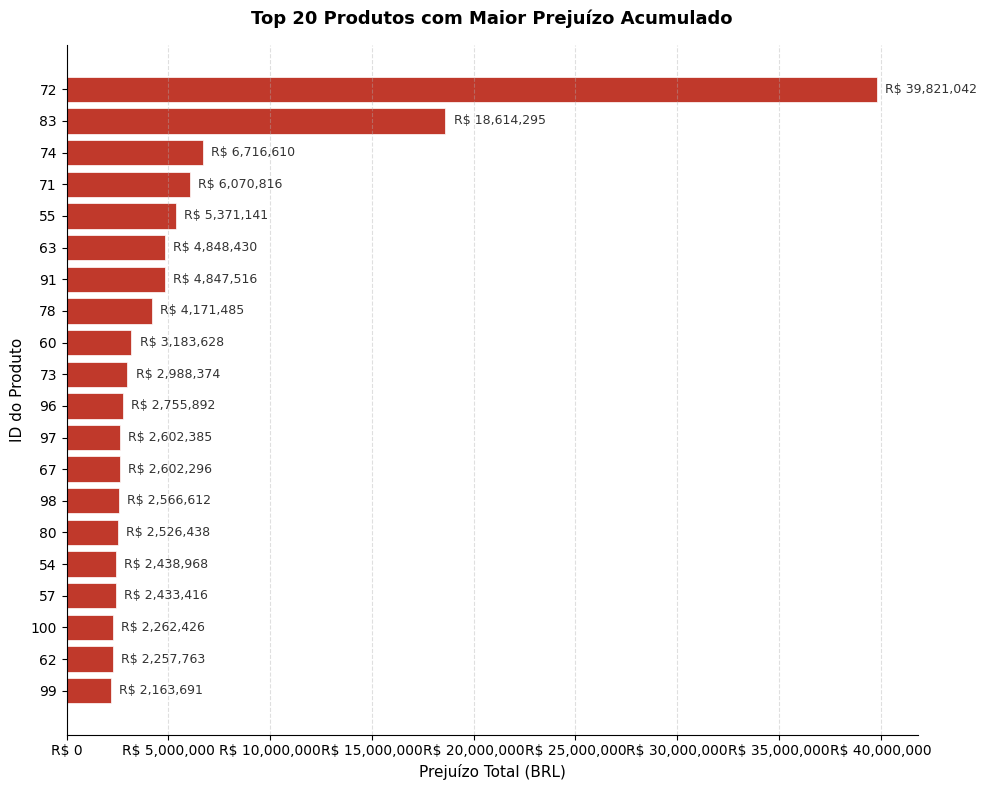

In [8]:
top20 = df_prejuizo.head(20).sort_values('prejuizo_total')

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    top20['id_product'].astype(str),
    top20['prejuizo_total'],
    color='#c0392b',
    edgecolor='white',
    linewidth=0.5
)

# Rótulo de valor em cada barra
for bar in bars:
    valor = bar.get_width()
    ax.text(
        valor + (top20['prejuizo_total'].max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'R$ {valor:,.0f}',
        va='center', ha='left', fontsize=9, color='#333333'
    )

ax.set_xlabel('Prejuízo Total (BRL)', fontsize=11)
ax.set_ylabel('ID do Produto', fontsize=11)
ax.set_title('Top 20 Produtos com Maior Prejuízo Acumulado', fontsize=13, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Explicação 

### Qual data de câmbio foi utilizada?

A cotação de venda do dólar do dia da venda obtida via API pública do Banco Central do Brasil.  
Para vendas realizadas em fins de semana ou feriados foi utilizado o câmbio do último dia útil anterior, via `merge_asof` com `direction='backward'`.

### Como o prejuízo foi definido?

Uma transação é considerada com prejuízo quando:

```
custo_total_brl = usd_price_vigente × câmbio_do_dia × qtd  >  total_recebido
```

O `usd_price_vigente` é o último preço de custo registrado antes ou na data da venda para aquele produto — ou seja, um join temporal que garante que não foi usado um custo futuro para avaliar uma venda passada.

### Suposições relevantes

| Suposição | Justificativa |
|---|---|
| Custo em USD é unitário | Premissa do enunciado |
| Câmbio de venda | A empresa converte BRL em USD para pagar o fornecedor |
| Impostos e frete ignorados | Premissa do enunciado |
| Receita total inclui todas as vendas | Premissa do enunciado — inclusive as lucrativas |
| Câmbio de feriado = último dia útil | Não há cotação oficial nesses dias |


## Exportar resultado final

In [9]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_por_produto.to_csv('../data/processed/prejuizo_por_produto.csv', index=False)
print('Salvo: ../data/processed/prejuizo_por_produto.csv')

df_final[['id', 'sale_date', 'id_product', 'qtd', 'total',
          'usd_price', 'usd_brl', 'custo_total_brl', 'resultado', 'prejuizo']]\
    .to_csv('../data/processed/vendas_com_custo.csv', index=False)
print('Salvo: ../data/processed/vendas_com_custo.csv')

Salvo: ../data/processed/prejuizo_por_produto.csv
Salvo: ../data/processed/vendas_com_custo.csv


# Questão 4.1 — SQL: Prejuízo por Produto

Algumas partes desse problema são difíceis de resolver apenas com SQL básico:

- Buscar o câmbio do dia (já que fins de semana não possuem cotação)
- Identificar o custo válido na data da venda (pois os preços mudam ao longo do tempo)

Por isso, essas etapas serão tratadas em Python. Em seguida, os dados já processados serão carregados no SQLite, permitindo consultas mais simples e claras.

Carregando dados

In [10]:
import json
import sqlite3
import requests
import pandas as pd

# Vendas
df_vendas = pd.read_csv('../data/raw/vendas_2023_2024.csv')

# Corrige os dois formatos de data
def parse_date(s):
    for fmt in ('%Y-%m-%d', '%d-%m-%Y'):
        try: return pd.to_datetime(s, format=fmt)
        except: pass

df_vendas['sale_date'] = df_vendas['sale_date'].apply(parse_date)

# Custos
with open('../data/raw/custos_importacao.json', 'r', encoding='utf-8') as f:
    custos_raw = json.load(f)

df_custos = pd.json_normalize(custos_raw, record_path='historic_data', meta=['product_id'])
df_custos['start_date'] = pd.to_datetime(df_custos['start_date'], format='%d/%m/%Y')
df_custos['product_id'] = df_custos['product_id'].astype(int)
df_custos = df_custos.sort_values(['product_id', 'start_date'])

print('Vendas:', len(df_vendas))
print('Registros de custo:', len(df_custos))

Vendas: 9895
Registros de custo: 1260


Buscando câmbio do BC

In [11]:
# Busca câmbio na API do Banco Central (série 1 = USD venda, média diária)
url = (
    "https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados"
    "?formato=json&dataInicial=01/01/2023&dataFinal=31/12/2024"
)
df_cambio = pd.DataFrame(requests.get(url, timeout=30).json())
df_cambio.columns = ['sale_date', 'usd_brl']
df_cambio['sale_date'] = pd.to_datetime(df_cambio['sale_date'], format='%d/%m/%Y')
df_cambio['usd_brl']   = df_cambio['usd_brl'].astype(float)

# merge_asof: para cada venda, pega o câmbio do dia ou do último dia útil anterior
df_vendas = df_vendas.sort_values('sale_date')
df_vendas = pd.merge_asof(df_vendas, df_cambio, on='sale_date', direction='backward')

print(f'Câmbio médio utilizado: R$ {df_vendas["usd_brl"].mean():.4f}')
df_vendas[['id', 'sale_date', 'usd_brl']].head()

Câmbio médio utilizado: R$ 5.1901


,id,sale_date,usd_brl
0,1230,2023-01-01,NaN
1,2300,2023-01-01,NaN
2,3131,2023-01-01,NaN
3,4212,2023-01-01,NaN
4,4294,2023-01-01,NaN


Associando o custo vigente a cada venda, pegando o último custo registrado antes ou na data da venda

In [12]:
resultados = []

for produto_id, vendas_produto in df_vendas.groupby('id_product'):
    custo_produto = df_custos[df_custos['product_id'] == produto_id]

    merged = pd.merge_asof(
        vendas_produto.sort_values('sale_date'),
        custo_produto[['start_date', 'usd_price']].rename(columns={'start_date': 'sale_date'}),
        on='sale_date',
        direction='backward'
    )
    resultados.append(merged)

df_final = pd.concat(resultados).reset_index(drop=True)

# Calcula custo em BRL e resultado
df_final['custo_total_brl'] = df_final['usd_price'] * df_final['usd_brl'] * df_final['qtd']
df_final['resultado']       = df_final['total'] - df_final['custo_total_brl']

print(f'Registros processados: {len(df_final)}')
df_final[['id', 'sale_date', 'id_product', 'total', 'custo_total_brl', 'resultado']].head()

Registros processados: 9895


,id,sale_date,id_product,total,custo_total_brl,resultado
0,1767,2023-01-03,1,33123.00,35148.70938,-2025.70938
1,6947,2023-01-12,1,220265.10,235244.43600,-14979.33600
2,5852,2023-01-16,1,62932.75,66840.01860,-3907.26860
3,9055,2023-01-25,1,94399.60,100116.84132,-5717.24132
4,1562,2023-01-26,1,264980.00,266502.26256,-1522.26256


Salvando tabela

In [13]:
conn = sqlite3.connect('../database/lighthouse.db')

df_final.to_sql('vendas_com_custo', conn, if_exists='replace', index=False)

n = conn.execute('SELECT COUNT(*) FROM vendas_com_custo').fetchone()[0]
print(f'Tabela vendas_com_custo criada com {n} linhas')

Tabela vendas_com_custo criada com 9895 linhas


In [14]:
query = """
SELECT
    id_product,

    -- Receita total: soma de todas as vendas do produto
    ROUND(SUM(total), 2) AS receita_total,

    -- Prejuízo total: soma apenas das transações onde o custo superou a receita
    ROUND(
        SUM(
            CASE WHEN resultado < 0 THEN ABS(resultado) ELSE 0 END
        )
    , 2) AS prejuizo_total,

    -- Percentual de perda: quanto do faturamento foi perdido
    ROUND(
        SUM(
            CASE WHEN resultado < 0 THEN ABS(resultado) ELSE 0 END
        ) / SUM(total) * 100
    , 2) AS percentual_perda

FROM vendas_com_custo

GROUP BY id_product

-- Mostra apenas produtos que tiveram algum prejuízo
HAVING prejuizo_total > 0

ORDER BY prejuizo_total DESC;
"""

df_resultado = pd.read_sql(query, conn)

print(f'Produtos com prejuízo: {len(df_resultado)}')
print(f'Prejuízo total: R$ {df_resultado["prejuizo_total"].sum():,.2f}')

df_resultado

Produtos com prejuízo: 150
Prejuízo total: R$ 182,144,538.90


,id_product,receita_total,prejuizo_total,percentual_perda
0,72,63057815.65,39821041.68,63.15
1,83,44377440.00,18614294.87,41.95
2,74,59764356.15,6716610.31,11.24
3,71,81567066.65,6070816.06,7.44
4,55,61224375.00,5371141.28,8.77
...,...,...,...,...
145,101,282745.90,11779.99,4.17
146,146,277313.60,10829.54,3.91
147,126,1388455.25,7634.69,0.55
148,105,145543.95,5110.18,3.51


In [15]:
conn.close()

## Questão 4.2 Validação
Qual é o id_produto que apresentou a maior porcentagem de perda financeira relativa (maior % de prejuízo sobre sua receita) no período analisado?

In [17]:
df_prejuizo.sort_values('percentual_perda', ascending=False).head(1)

,id_product,receita_total,prejuizo_total,percentual_perda
0,72,63057815.65,3.982104e+07,63.15


## Questão 4.3 — Explicação do Desenvolvimento

### Qual data de câmbio foi utilizada?

A cotação de venda do dólar do **dia da venda, obtida via API pública do Banco Central do Brasil. Para vendas realizadas em fins de semana ou feriados — dias em que o Banco Central não divulga cotação — foi utilizado o câmbio do último dia útil anterior, usando `merge_asof` com `direction='backward'`.

---

### Como o prejuízo foi definido?

Uma transação é considerada com prejuízo quando o custo total em BRL supera o valor recebido na venda:
```
custo_total_brl = usd_price_vigente × câmbio_do_dia × qtd
prejuízo        = custo_total_brl - total  (considerado apenas quando positivo)
```

O `usd_price_vigente` é o último preço de custo registrado antes ou na data da venda para aquele produto, garantindo que não foi usado um custo futuro para avaliar uma venda passada.

---

### Suposições relevantes

| Suposição | Justificativa |
|---|---|
| Custo em USD é unitário | Premissa do enunciado |
| Câmbio de venda (não compra) | A empresa converte BRL em USD para pagar o fornecedor estrangeiro |
| Impostos e frete ignorados | Premissa do enunciado |
| Receita total inclui todas as vendas | Premissa do enunciado — inclusive as transações lucrativas |
| Câmbio de feriado = último dia útil | Não há cotação oficial nesses dias pelo Banco Central |